# TransFit Tutorial: Fitting the Example Data

This notebook fits the two example data files shipped with TransFit:

- `sn1993j_lbol.txt`: bolometric luminosity data.
- `sn2007gr.csv`: multi-band `B/V/R/I` photometry.

Both examples use the `nickel` model and run `emcee` with `nsteps=5000`.

In [1]:
from pathlib import Path
import sys

# Make the notebook work both from the repository root and from examples/.
CWD = Path.cwd().resolve()
if (CWD / "transfit").is_dir():
    REPO_ROOT = CWD
elif (CWD.parent / "transfit").is_dir():
    REPO_ROOT = CWD.parent
else:
    raise RuntimeError("Could not locate the local TransFit repository root.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import transfit as tf

DATA_DIR = REPO_ROOT / "examples" / "data"
OUT_DIR = REPO_ROOT / "mcmc_out"
OUT_DIR.mkdir(exist_ok=True)
print("Using TransFit from:", Path(tf.__file__).resolve())

Using TransFit from: C:\Users\zyh\Desktop\TransFit\transfit\__init__.py


## 1. Load the example data

In [2]:
def load_sn1993j_bolometric():
    arr = np.loadtxt(DATA_DIR / "sn1993j_lbol.txt", comments="#")
    t_days = arr[:, 0] - np.nanmin(arr[:, 0])
    return tf.BolometricData(
        t_days=t_days,
        y=arr[:, 1],
        yerr=arr[:, 2],
    )


def load_sn2007gr_multiband():
    df = pd.read_csv(DATA_DIR / "sn2007gr.csv")
    phase = np.asarray(df["Phase"], float)
    t0 = float(np.nanmin(phase))

    mag_cols = {
        "B": ("Bmag", "e_Bmag"),
        "V": ("Vmag", "e_Vmag"),
        "R": ("Rmag", "e_Rmag"),
        "I": ("Imag", "e_Imag"),
    }

    t_days, bands, y, yerr = [], [], [], []
    for band, (mcol, ecol) in mag_cols.items():
        mag = pd.to_numeric(df[mcol], errors="coerce").to_numpy(float)
        err = pd.to_numeric(df[ecol], errors="coerce").to_numpy(float)
        good = np.isfinite(phase) & np.isfinite(mag) & np.isfinite(err) & (err > 0.0)
        t_days.extend((phase[good] - t0).tolist())
        y.extend(mag[good].tolist())
        yerr.extend(err[good].tolist())
        bands.extend([band] * int(np.sum(good)))

    order = np.argsort(np.asarray(t_days, float))
    return tf.MultiBandData(
        t_days=np.asarray(t_days, float)[order],
        band=np.asarray(bands, dtype=object)[order],
        y=np.asarray(y, float)[order],
        yerr=np.asarray(yerr, float)[order],
    )


bol_data = load_sn1993j_bolometric()
mb_data = load_sn2007gr_multiband()

print(f"SN1993J bolometric points: {bol_data.t_days.size}")
print(f"SN2007gr multiband points: {mb_data.t_days.size}, bands: {mb_data.bands}")

SN1993J bolometric points: 89
SN2007gr multiband points: 307, bands: ['B', 'I', 'R', 'V']


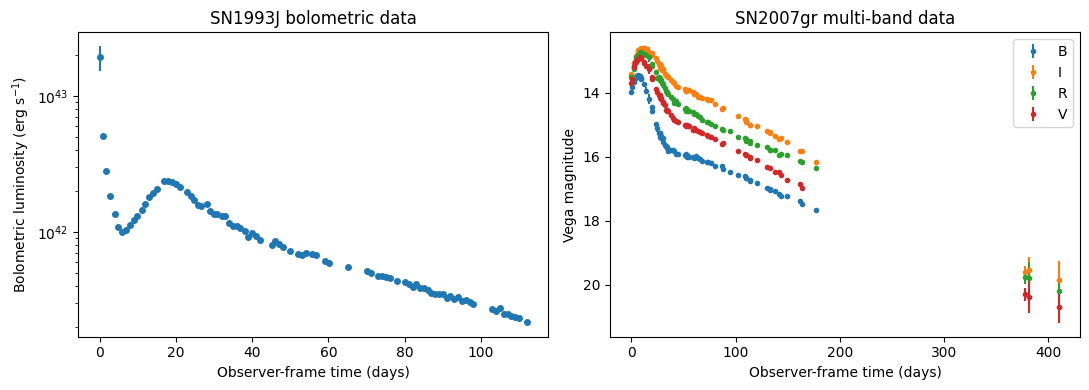

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].errorbar(bol_data.t_days, bol_data.y, yerr=bol_data.yerr, fmt="o", ms=4)
axes[0].set_yscale("log")
axes[0].set_xlabel("Observer-frame time (days)")
axes[0].set_ylabel("Bolometric luminosity (erg s$^{-1}$)")
axes[0].set_title("SN1993J bolometric data")

for band in mb_data.bands:
    m = mb_data.band == band
    axes[1].errorbar(mb_data.t_days[m], mb_data.y[m], yerr=mb_data.yerr[m], fmt=".", ms=6, label=band)
axes[1].invert_yaxis()
axes[1].set_xlabel("Observer-frame time (days)")
axes[1].set_ylabel("Vega magnitude")
axes[1].set_title("SN2007gr multi-band data")
axes[1].legend()

fig.tight_layout()

## 2. Shared model and sampler settings

In [4]:
print(tf.model_param_names("nickel"))

EMCEE_5000 = {
    "nwalkers": 48,
    "nsteps": 5000,
    "burnin": 1000,
    "thin": 10,
    "seed": 123,
    "progress": False,
    "robust_init": True,
}

nickel_priors = {
    "M_ej": (0.3, 8.0),
    "v_ej": (0.2, 4.0),
    "E_Th_in": (0.01, 80.0),
    "M_ni": ("log10", -3.0, -0.2),
    "R_0": (10.0, 2000.0),
    "f_ni": (0.02, 0.9),
    "kappa": (0.02, 0.4),
    "kappa_gamma": (0.003, 0.2),
    "t_shift": (0.0, 15.0),
}

fixed_bol = {
    "sigma_int": 0.08,
}

fixed_multiband = {
    "f_ni": 0.2,
    "kappa": 0.12,
    "kappa_gamma": 0.03,
    "T_floor": 4500.0,
}

filters = {
    "B": "johnson_cousins.B",
    "V": "johnson_cousins.V",
    "R": "johnson_cousins.R",
    "I": "johnson_cousins.I",
}

['M_ej', 'v_ej', 'E_Th_in', 'M_ni', 'R_0', 'f_ni', 'kappa', 'kappa_gamma', 'T_floor']


## 3. Fit `sn1993j_lbol.txt` with `emcee`

All bolometric points are included in the likelihood. The example uses a small fixed `sigma_int` term because the tabulated bolometric errors are much smaller than the model/data systematics, especially during the early cooling phase.

In [5]:
res_bol = tf.fit_bol(
    data=bol_data,
    model="nickel",
    z=0.001728,
    priors=nickel_priors,
    fixed=fixed_bol,
    sampler="emcee",
    sampler_kwargs=EMCEE_5000,
)

print("Bolometric fit samples:", res_bol.samples.shape)
print("Bolometric best log_prob:", res_bol.best_log_prob)
res_bol.best_params_raw

Bolometric fit samples: (24000, 9)
Bolometric best log_prob: -8454.63095898591


{'M_ej': 1.6140294643966668,
 'v_ej': 1.659564575006545,
 'E_Th_in': 6.132887838342336,
 'M_ni': 0.10144748301939104,
 'R_0': 412.2109295916323,
 'f_ni': 0.4281614210181024,
 'kappa': 0.1682027101457051,
 'kappa_gamma': 0.1754993702832019,
 't_shift': 0.23621597743015188,
 'sigma_int': 0.08}

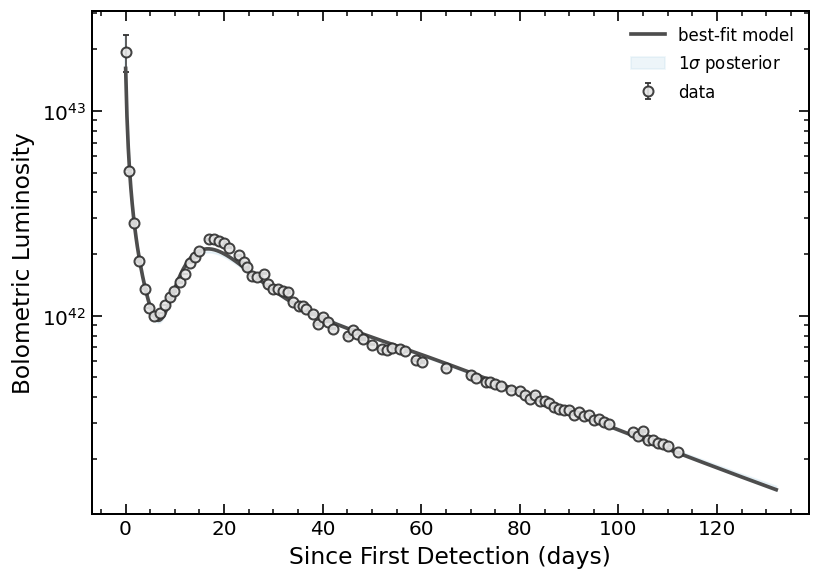

In [6]:
fig_bol = tf.plot.fit_bol(
    res_bol,
    data=bol_data,
    show_1sigma=True,
    n_draws=100,
    n_t=500,
    t_pad=20.0,
)
fig_bol

## 4. Fit `sn2007gr.csv` with `emcee`

In [7]:
res_mb = tf.fit_multiband(
    data=mb_data,
    model="nickel",
    z=0.001728,
    filters=filters,
    y_kind="mag",
    mag_system="vega",
    priors=nickel_priors,
    fixed=fixed_multiband,
    sampler="emcee",
    sampler_kwargs={**EMCEE_5000, "seed": 456},
)

print("Multi-band fit samples:", res_mb.samples.shape)
print("Multi-band best log_prob:", res_mb.best_log_prob)
res_mb.best_params_raw

Multi-band fit samples: (24000, 6)
Multi-band best log_prob: -4124.743073839144


{'M_ej': 0.9719570062164588,
 'v_ej': 0.3147292412513066,
 'E_Th_in': 0.7864026776929343,
 'M_ni': 0.03499909223165951,
 'R_0': 1999.837426342742,
 'f_ni': 0.2,
 'kappa': 0.12,
 'kappa_gamma': 0.03,
 'T_floor': 4500.0,
 't_shift': 7.935759115527933}

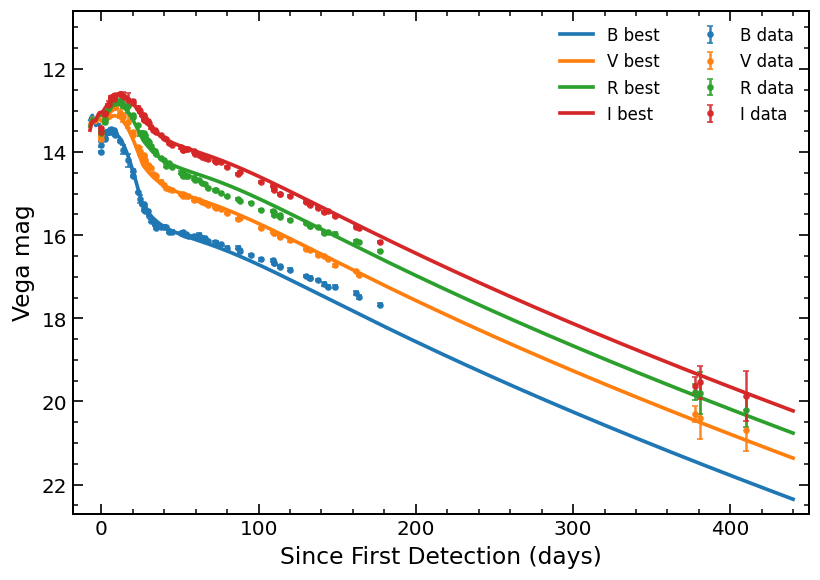

In [8]:
fig_mb = tf.plot.fit_multiband(
    res_mb,
    data=mb_data,
    show_1sigma=False,
    n_t=600,
    t_pad=30.0,
)
fig_mb

## 5. Save the results

In [9]:
bol_path = tf.save(res_bol, OUT_DIR / "tutorial_sn1993j_bol_emcee5000.npz")
mb_path = tf.save(res_mb, OUT_DIR / "tutorial_sn2007gr_multiband_emcee5000.npz")

print("Saved bolometric result:", bol_path)
print("Saved multi-band result:", mb_path)
print("Loaded bolometric samples:", tf.load(bol_path)["samples"].shape)
print("Loaded multi-band samples:", tf.load(mb_path)["samples"].shape)

Saved bolometric result: C:\Users\zyh\Desktop\TransFit\mcmc_out\tutorial_sn1993j_bol_emcee5000.npz
Saved multi-band result: C:\Users\zyh\Desktop\TransFit\mcmc_out\tutorial_sn2007gr_multiband_emcee5000.npz
Loaded bolometric samples: (24000, 9)
Loaded multi-band samples: (24000, 6)


## 6. Plot saved results manually

The plotting helpers above are optional. A saved fit result can be loaded with `tf.load()` and plotted with plain Matplotlib. The key steps are:

1. Find the sample with the largest `log_prob`.
2. Merge that sampled vector with the fixed parameters.
3. Evaluate the model with `tf.predict_bol()` or `tf.predict_multiband()`.
4. Plot the data and model yourself.

When a fitted result contains `t_shift`, keep the x-axis in observed days and evaluate the model at `t_obs + t_shift`.

In [10]:
def best_params_from_saved_result(path):
    """Load a saved TransFit result and rebuild the best-fit parameter dict."""
    loaded = tf.load(path)
    samples = np.asarray(loaded["samples"], float)
    log_prob = np.asarray(loaded["log_prob"], float)
    param_names = [str(x) for x in loaded["param_names"]]

    score = np.where(np.isfinite(log_prob), log_prob, -np.inf)
    best_index = int(np.argmax(score))

    params = {str(k): float(v) for k, v in dict(loaded["fixed"]).items()}
    params.update({name: float(value) for name, value in zip(param_names, samples[best_index])})

    # Compatibility for result files saved before the public nickel parameter rename.
    rename = {"M_Ni": "M_ni", "x_Ni": "f_ni"}
    for old, new in rename.items():
        if old in params and new not in params:
            params[new] = params.pop(old)
        else:
            params.pop(old, None)

    return loaded, params, best_index


def model_params_and_t_shift(loaded, params):
    """Keep only forward-model parameters; drop fit-only terms such as sigma_int."""
    all_names = [str(x) for x in loaded.get("all_param_names", []) if str(x)]
    if not all_names:
        all_names = tf.model_param_names(str(loaded["model"]), include_t_shift=True)

    t_shift = float(params.get("t_shift", 0.0))
    model_params = {name: float(params[name]) for name in all_names if name != "t_shift" and name in params}
    return model_params, t_shift


def builtin_filter_ids_from_saved_result(loaded):
    """Recover a simple band -> builtin filter id mapping from saved context metadata."""
    out = {}
    for band, spec in loaded["ctx"].get("filters", {}).items():
        out[str(band)] = spec.get("filter_id", spec.get("nu_eff_hz"))
    return out

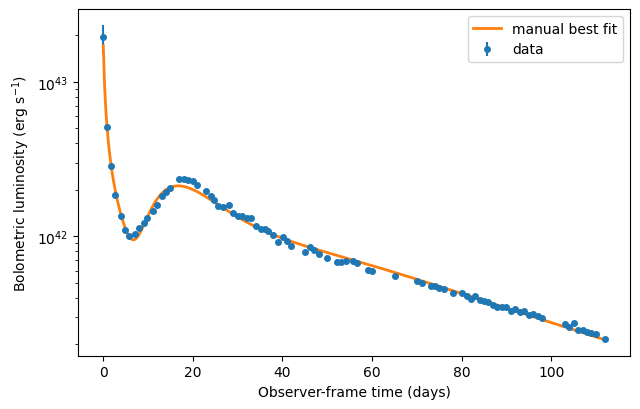

Best bolometric sample index: 3418


{'sigma_int': 0.08,
 'M_ej': 1.6140294643966668,
 'v_ej': 1.659564575006545,
 'E_Th_in': 6.132887838342336,
 'M_ni': 0.10144748301939104,
 'R_0': 412.2109295916323,
 'f_ni': 0.4281614210181024,
 'kappa': 0.1682027101457051,
 'kappa_gamma': 0.1754993702832019,
 't_shift': 0.23621597743015188}

In [11]:
loaded_bol, bol_best_params, bol_best_index = best_params_from_saved_result(bol_path)
bol_model_params, t_shift_bol = model_params_and_t_shift(loaded_bol, bol_best_params)

z_bol = loaded_bol["ctx"]["distance"]["z"]
t_plot = np.linspace(0.0, float(np.nanmax(bol_data.t_days)), 400)

L_model = tf.predict_bol(
    model=loaded_bol["model"],
    params=bol_model_params,
    z=z_bol,
    t_days=t_plot + t_shift_bol,
    t_max_days=max(120.0, float(np.nanmax(t_plot + t_shift_bol)) + 20.0),
    interp_fill="nan",
)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(bol_data.t_days, bol_data.y, yerr=bol_data.yerr, fmt="o", ms=4, label="data")
ax.plot(t_plot, L_model, lw=2.0, label="manual best fit")
ax.set_yscale("log")
ax.set_xlabel("Observer-frame time (days)")
ax.set_ylabel("Bolometric luminosity (erg s$^{-1}$)")
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)

print("Best bolometric sample index:", bol_best_index)
bol_best_params

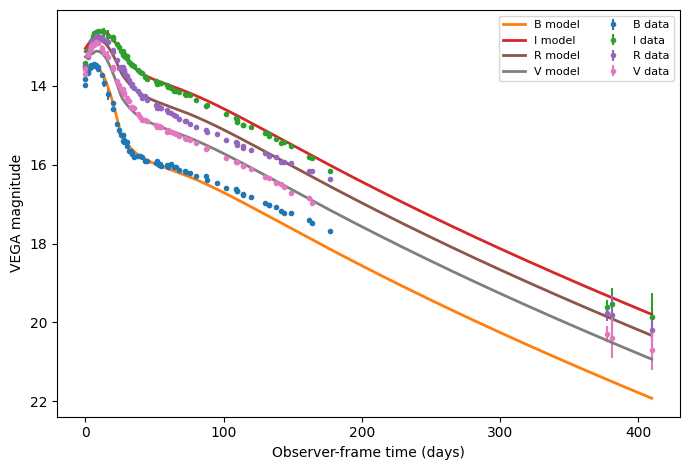

Best multi-band sample index: 5698


{'f_ni': 0.2,
 'kappa': 0.12,
 'kappa_gamma': 0.03,
 'T_floor': 4500.0,
 'M_ej': 0.9719570062164588,
 'v_ej': 0.3147292412513066,
 'E_Th_in': 0.7864026776929343,
 'M_ni': 0.03499909223165951,
 'R_0': 1999.837426342742,
 't_shift': 7.935759115527933}

In [12]:
loaded_mb, mb_best_params, mb_best_index = best_params_from_saved_result(mb_path)

ctx_mb = loaded_mb["ctx"]
z_mb = ctx_mb["distance"]["z"]
y_kind_mb = ctx_mb["photometry"]["y_kind"]
mag_system_mb = ctx_mb["photometry"]["mag_system"]
saved_filters = builtin_filter_ids_from_saved_result(loaded_mb)
mb_model_params, t_shift_mb = model_params_and_t_shift(loaded_mb, mb_best_params)

bands_to_plot = list(mb_data.bands)
t_grid = np.linspace(0.0, float(np.nanmax(mb_data.t_days)), 400)
t_eval = np.tile(t_grid, len(bands_to_plot))
band_eval = np.repeat(np.asarray(bands_to_plot, dtype=object), t_grid.size)

model_mag = tf.predict_multiband(
    model=loaded_mb["model"],
    params=mb_model_params,
    z=z_mb,
    filters=saved_filters,
    t_days=t_eval + t_shift_mb,
    band=band_eval,
    y_kind=y_kind_mb,
    mag_system=mag_system_mb,
    t_max_days=max(120.0, float(np.nanmax(t_eval + t_shift_mb)) + 20.0),
    interp_fill="nan",
)

fig, ax = plt.subplots(figsize=(7.0, 4.8))
for band in bands_to_plot:
    data_mask = mb_data.band == band
    model_mask = band_eval == band
    ax.errorbar(
        mb_data.t_days[data_mask],
        mb_data.y[data_mask],
        yerr=mb_data.yerr[data_mask],
        fmt=".",
        ms=6,
        label=f"{band} data",
    )
    ax.plot(t_grid, model_mag[model_mask], lw=2.0, label=f"{band} model")

if y_kind_mb == "mag":
    ax.invert_yaxis()
ax.set_xlabel("Observer-frame time (days)")
ax.set_ylabel(f"{mag_system_mb.upper()} magnitude" if y_kind_mb == "mag" else "Flux density")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)

print("Best multi-band sample index:", mb_best_index)
mb_best_params